# PyMC-BART Wrapper: Multiclass Categorical and Ordinal Classification

This notebook demonstrates the `BARTModelWrapper` class from `pymc_bart_wrapper.py` for two ways of building classification models on the `modelDataDeIdentified.csv` dataset by target variable type:

1. **Categorical:** Uses `pmb.BART` → softmax → `pm.Categorical` likelihood
2. **Ordinal:** Uses `pmb.BART` (1-D latent) → `pm.OrderedLogistic` with learned cutpoints

> **Reference:** The wrapper follows the model specification from the [PyMC-BART categorical regression example](https://www.pymc.io/projects/bart/en/latest/examples/bart_categorical_hawks.html) and [PyMC orginal regression example](https://www.pymc.io/projects/examples/en/latest/statistical_rethinking_lectures/11-Ordered_Categories.html)

## 1. Import Libraries and Load Data

Import libraries: `pandas` and `numpy` for data handling, `matplotlib` and `seaborn` for visualization, `scikit-learn` for splitting and evaluation metrics, `arviz` for Bayesian diagnostics, and our custom `BARTModelWrapper` class.

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import arviz as az
from pathlib import Path
from sklearn.model_selection import train_test_split
from sklearn.metrics import confusion_matrix, classification_report, accuracy_score
from pymc_bart_wrapper import BARTModelWrapper

sns.set_style("whitegrid")

In [2]:
# Load the dataset (supports both CSV and Parquet)
DATA_PATH = Path('./data/modelDataDeIdentified.parquet')
if DATA_PATH.suffix == '.csv':
    df = pd.read_csv(DATA_PATH)
elif DATA_PATH.suffix == '.parquet':
    df = pd.read_parquet(DATA_PATH)
else:
    raise ValueError(f"Unsupported file format: {DATA_PATH.suffix}")

print(f"Dataset shape: {df.shape}")
print(f"Columns: {df.columns.tolist()}")

Dataset shape: (5011, 58)
Columns: ['finalized_label', 'sex', 'pat_age_at_test', 'hgb_a', 'hgb_f', 'hgb_s', 'hgb_c', 'hgb_a2', 'hgb_a2_variant', 'hgb_e', 'hgb_barts', 'hgb_h', 'hgb_d', 'hgb_other_hgb', 'total_hgb_count', 'hgb_a_category', 'hgb_f_category', 'hgb_s_category', 'hgb_c_category', 'hgb_a2_category', 'hgb_a2_variant_category', 'hgb_e_category', 'hgb_barts_category', 'hgb_h_category', 'hgb_d_category', 'hgb_other_hgb_category', 'total_hgb_count_category', 'agar_gel_electrophoresis', 'hemoglobinopathies', 'rbc_mean', 'rbc_sd', 'hgb_mean', 'hgb_sd', 'hct_mean', 'hct_sd', 'mcv_mean', 'mcv_sd', 'rdw_cv_mean', 'rdw_cv_sd', 'calculated_tibc_mean', 'calculated_tibc_sd', 'hemolysis_mean', 'hemolysis_sd', 'icterus_mean', 'icterus_sd', 'iron_mean', 'iron_sd', 'tfn_saturation_mean', 'tfn_saturation_sd', 'transferrin_mean', 'transferrin_sd', 'turbidity_mean', 'turbidity_sd', 'prior_cbc', 'prior_iron', 'prior_nbs', 'prior_acid_gel', 'weights']


## 2. Explore the Dataset

Let's examine the dataset: view the first few rows, check the unique target classes in `finalized_label`, and visualize the class distribution.

In [3]:
df.head()

,finalized_label,sex,pat_age_at_test,hgb_a,hgb_f,hgb_s,hgb_c,hgb_a2,hgb_a2_variant,hgb_e,...,tfn_saturation_sd,transferrin_mean,transferrin_sd,turbidity_mean,turbidity_sd,prior_cbc,prior_iron,prior_nbs,prior_acid_gel,weights
0,Normal,F,34.294541,98.2,0.0,0.0,0.0,1.8,0.0,0.0,...,NaN,NaN,NaN,NaN,NaN,2.0,0.0,0.0,0.0,0.561234
1,Normal,M,64.047655,97.3,0.0,0.0,0.0,2.7,0.0,0.0,...,NaN,306.0,NaN,NaN,NaN,5.0,1.0,0.0,0.0,0.561234
2,Beta_Thalassemia,F,55.918830,94.0,1.0,0.0,0.0,5.0,0.0,0.0,...,NaN,NaN,NaN,NaN,NaN,2.0,0.0,0.0,0.0,1.813820
3,Normal,M,27.716840,97.2,0.0,0.0,0.0,2.8,0.0,0.0,...,NaN,NaN,NaN,NaN,NaN,5.0,0.0,0.0,0.0,0.561234
4,Normal,F,21.527275,97.8,0.0,0.0,0.0,2.2,0.0,0.0,...,NaN,NaN,NaN,NaN,NaN,2.0,0.0,0.0,0.0,0.561234


In [4]:
print(f"Target classes: {df['finalized_label'].unique().tolist()}")
print(f"\nTarget distribution:")
print(df['finalized_label'].value_counts())

Target classes: ['Normal', 'Beta_Thalassemia', 'Sickle_Cell_Disease', 'Other', 'HGB_SC_Disease', 'Sickle_Cell_Trait', 'Hemoglobin_C_Trait']

Target distribution:
finalized_label
Normal                 3217
Other                   535
Sickle_Cell_Trait       491
Beta_Thalassemia        308
Sickle_Cell_Disease     203
Hemoglobin_C_Trait      141
HGB_SC_Disease          116
Name: count, dtype: int64


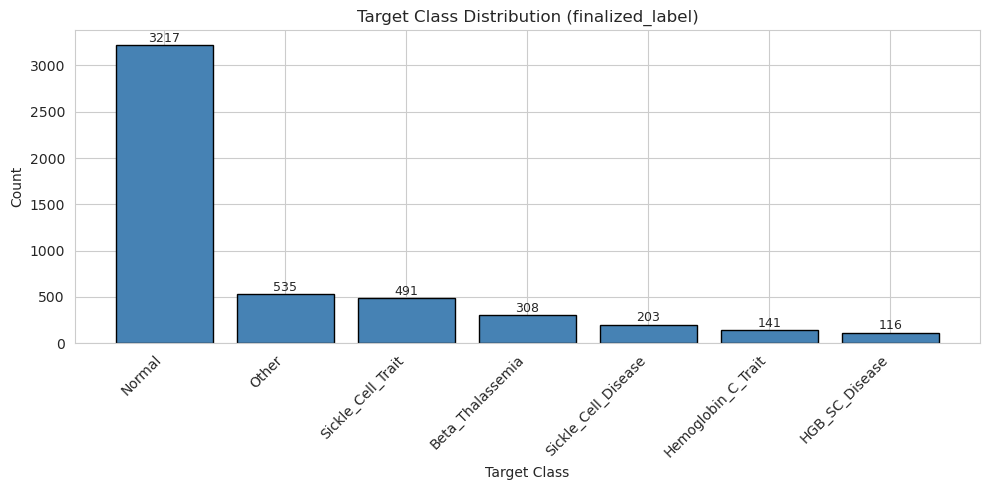

In [6]:
# Bar chart of target class distribution
fig, ax = plt.subplots(figsize=(10, 5))
target_counts = df['finalized_label'].value_counts()
bars = ax.bar(target_counts.index, target_counts.values, color="steelblue", edgecolor="black")
ax.set_xlabel("Target Class")
ax.set_ylabel("Count")
ax.set_title("Target Class Distribution (finalized_label)")
plt.xticks(rotation=45, ha="right")
for bar, count in zip(bars, target_counts.values):
    ax.text(bar.get_x() + bar.get_width() / 2, bar.get_height() + 1,
            str(count), ha="center", va="bottom", fontsize=9)
plt.tight_layout()

## 3. Define Variables and Train/Test Split

Define the **target variable** (`finalized_label`), the **predictor variables** (a mix of numeric and categorical features), and the **non-numeric variables** that require one-hot encoding. A **subset** of the all available variables are selected for demonstration. Then we perform a stratified 80/20 train/test split to preserve class proportions.

In [10]:
TARGET = "finalized_label"

PREDICTOR_VARS = [
    # Numeric predictors
    "pat_age_at_test",
    "hgb_a", "hgb_f", "hgb_s", "hgb_c",
    "hgb_a2", "hgb_a2_variant",
    "hgb_e", "hgb_barts", "hgb_h", "hgb_d",
    "hgb_other_hgb", "total_hgb_count",
    "rbc_mean", "hgb_mean", "hct_mean", "mcv_mean", "rdw_cv_mean",
    # Categorical predictors
    "sex",
    "hgb_a_category", "hgb_s_category", "hgb_c_category",
]

NON_NUMERIC_VARS = [
    "sex",
    "hgb_a_category", "hgb_s_category", "hgb_c_category",
]

print(f"Target variable: {TARGET}")
print(f"Number of predictors: {len(PREDICTOR_VARS)}")
print(f"  Numeric: {len(PREDICTOR_VARS) - len(NON_NUMERIC_VARS)}")
print(f"  Categorical (to be one-hot encoded): {len(NON_NUMERIC_VARS)}")
print(f"  Non-numeric vars: {NON_NUMERIC_VARS}")

Target variable: finalized_label
Number of predictors: 22
  Numeric: 18
  Categorical (to be one-hot encoded): 4
  Non-numeric vars: ['sex', 'hgb_a_category', 'hgb_s_category', 'hgb_c_category']


In [11]:
# Stratified train/test split (80/20)
df_train, df_test = train_test_split(
    df, test_size=0.2, random_state=42, stratify=df[TARGET]
)

print(f"Train size: {len(df_train)}")
print(f"Test  size: {len(df_test)}")

Train size: 4008
Test  size: 1003


## 4.1. Run Data Preprocessing - From Training Data

**PyMC-BART does not natively handle categorical (string) features and missing values.** The `BARTModelWrapper` addresses this by applying **one-hot encoding** via scikit-learn's `OneHotEncoder` to all columns listed in `non_numeric_vars`. In addition, numeric columns with missing values are filled with a out-of-range value (default `-99` as our numeric columns are > 0) to allow the BART trees to learn from "missingness" as a feature, while categorical columns with missing values are filled with a new `"missing"` category.

The preprocessing method `preprocess()` works as follows:

1. **Numeric columns** with missing values are filled with a out-of-range value (default `-99`) when `fill_missing=True`. This places missing values outside the normal data range so the BART trees can learn to split on "missingness" as a feature.
2. **Categorical columns** with missing values are filled with a new `"missing"` category, which the one-hot encoder then treats as just another level.
3. If `fill_missing=False`, rows containing **any** NaN (across target + selected predictors) are dropped instead.
4. Categorical columns are **one-hot encoded** — each unique category becomes a binary (0/1) column. For example, `sex` with values `["M", "F"]` becomes two columns: `sex_F` and `sex_M`.
5. The **target variable** is integer-encoded (factorized) so each class label maps to a code `0, 1, 2, ...`.

In [ ]:
# Demonstrate preprocessing: instantiate a temporary wrapper and call preprocess()
demo_wrapper = BARTModelWrapper(
    target_var=TARGET,
    predictor_vars=PREDICTOR_VARS,
    non_numeric_vars=NON_NUMERIC_VARS,
    target_type="categorical",
    fill_missing=True,
    missing_numeric_fill=-99,
)

# preprocess with fit=True learns encoders and returns (X, y_codes)
# for the predcition, encoders learned during the fitting will be used
X_demo, y_codes_demo = demo_wrapper.preprocess(df_train, fit=True)

print(f"Processed predictor matrix X shape: {X_demo.shape}")
print(f"Original predictor count: {len(PREDICTOR_VARS)}")
print(f"After one-hot encoding:   {X_demo.shape[1]} columns")
print(f"\nColumns after encoding:\n{X_demo.columns.tolist()}")
print(f"\nUnique target codes: {np.unique(y_codes_demo)}")
print(f"Category mapping: {demo_wrapper.category_map_}")

In [ ]:
# Show the first few rows of the processed predictor matrix
X_demo.head()

## 4.2. Run Data Preprocessing - Data Registration with `register_data()`

The `register_data(df)` method pre-fits the one-hot encoder and target encoding on the full dataset before the train/test split. This is an important step because:

- **Every category is represented:** If a rare category appears only in the test set, the one-hot encoder (fitted only on the training set) would not know about it and would produce an all-zeros row. Pre-fitting on the full data avoids this.
- **Optional but recommended:** If `register_data()` is never called, encoders are learned from the training set only during `fit()`.

Internally, `register_data()`:
1. Identifies numeric vs. categorical predictor columns.
2. Fills missing categorical values with `"missing"` (if `fill_missing=True`).
3. Learns the target encoding (`category_codes_`, `category_map_`, `n_classes_`).
4. Fits the `OneHotEncoder` on all categorical predictor columns from the full dataset.
5. Sets `encoder_fitted_ = True` so that `preprocess()` and `fit()` reuse these pre-fitted encoders.

In [ ]:
# Demonstrate register_data(): pre-fit encoders on the FULL dataset
reg_demo = BARTModelWrapper(
    target_var=TARGET,
    predictor_vars=PREDICTOR_VARS,
    non_numeric_vars=NON_NUMERIC_VARS,
    target_type="categorical",
    fill_missing=True,
)

# Register the full dataset
reg_demo.register_data(df)

# Inspect what was learned
print(f"encoder_fitted_: {reg_demo.encoder_fitted_}")
print(f"\nTarget classes (category_codes_):\n  {reg_demo.category_codes_.tolist()}")
print(f"\nCategory map (code → label):\n  {reg_demo.category_map_}")
print(f"\nn_classes_: {reg_demo.n_classes_}")
print(f"\nOne-hot encoded columns (ohe_columns_):\n  {reg_demo.ohe_columns_}")

---

## 5. Example A: Multiclass Categorical BART Model

### Example A: Setup and Fit

For `target_type="categorical"`, the wrapper builds a PyMC model with the following structure:

1. `pmb.BART("mu", X, y, m=50, dims=["classes", "n_obs"])` — The BART prior produces a matrix of latent scores `mu` with shape `(n_classes, n_obs)`. Each element represents the "log-odds-like" score for a given class and observation.
2. `theta = softmax(mu, axis=0)` — The softmax function converts the raw latent scores into proper class probabilities that sum to 1 across classes for each observation.
3. `pm.Categorical("y", p=theta.T, observed=y_codes)` — The categorical likelihood draws observed class labels from the class probability vector.

The number of trees `m=50` controls the number of trees. We use `chains=2, draws=500, tune=500` for faster demo execution (increase for production use).

In [12]:
# Instantiate the categorical wrapper
cat_wrapper = BARTModelWrapper(
    target_var=TARGET,
    predictor_vars=PREDICTOR_VARS,
    non_numeric_vars=NON_NUMERIC_VARS,
    target_type="categorical",       # unordered multiclass
    fill_missing=True,               # fill NaN with missing_numeric_fill / "missing"
    missing_numeric_fill=-99,        # custom fill value for missing numerics
)

# Pre-fit encoders on the full dataset so every category is known
cat_wrapper.register_data(df)
print(cat_wrapper)

BARTModelWrapper(target='finalized_label', target_type='categorical', n_predictors=22, fill_missing=True, encoding=full-data, status=not fitted)


In [13]:
# Fit the categorical BART model
# (reduced draws/trees for demo speed; increase for real analysis)
cat_wrapper.fit(
    df_train,
    m=50,
    chains=2,
    draws=500,
    tune=500,
    random_seed=42,
)
print("Categorical model fitted.")

Sequential sampling (2 chains in 1 job)
PGBART: [mu]


Output()

Sampling 2 chains for 500 tune and 500 draw iterations (1_000 + 1_000 draws total) took 244 seconds.
Sampling: [y]


Output()

Categorical model fitted.


### Example A: Inspect Inference Data and Posterior Summary

After fitting, we can retrieve the ArviZ `InferenceData` object, which contains the posterior samples, posterior predictive draws, and other diagnostics. The `summary()` method provides a convenient table of posterior statistics.

In [14]:
# Retrieve the ArviZ InferenceData object
idata_cat = cat_wrapper.get_inference_data()
print(idata_cat)

Inference data with groups:
	> posterior
	> posterior_predictive
	> sample_stats
	> observed_data
	> constant_data


In [15]:
# Posterior summary table
cat_wrapper.summary()

,mean,sd,hdi_3%,hdi_97%,mcse_mean,mcse_sd,ess_bulk,ess_tail,r_hat
"mu[Beta_Thalassemia, 0]",6.711,0.886,4.922,8.164,0.279,0.076,9.0,67.0,1.21
"mu[Beta_Thalassemia, 1]",6.291,0.830,4.501,7.626,0.133,0.066,39.0,77.0,1.09
"mu[Beta_Thalassemia, 2]",4.147,0.797,2.487,5.477,0.149,0.066,29.0,45.0,1.07
"mu[Beta_Thalassemia, 3]",6.708,0.871,5.082,8.252,0.246,0.075,12.0,58.0,1.18
"mu[Beta_Thalassemia, 4]",7.415,0.805,5.787,8.934,0.267,0.067,9.0,61.0,1.21
...,...,...,...,...,...,...,...,...,...
"theta[6, 4003]",0.001,0.001,0.000,0.003,0.000,0.000,73.0,221.0,1.04
"theta[6, 4004]",0.049,0.029,0.010,0.106,0.003,0.002,73.0,187.0,1.01
"theta[6, 4005]",0.009,0.007,0.001,0.022,0.001,0.001,81.0,175.0,1.03
"theta[6, 4006]",0.003,0.002,0.000,0.007,0.000,0.000,89.0,230.0,1.01


### Example A: Out-of-Sample Prediction

Now generate predictions on the held-out test set using `cat_wrapper.predict()`. This method:

1. Preprocesses `df_test` using the same encoding learned during registration/training.
2. Swaps the shared covariate matrix with the test data.
3. Draws from the full posterior predictive distribution.
4. Returns predicted labels, class probabilities, and raw posterior predictive draws.

In [16]:
# Predict on held-out test data
results_cat = cat_wrapper.predict(df_test, random_seed=42)

print(f"Predicted labels (first 10): {results_cat['predicted_labels'][:10]}")
print(f"Class prob mean shape: {results_cat['class_prob_mean'].shape}")
print(f"Posterior predictive shape: {results_cat['posterior_predictive'].shape}")

Sampling: [mu, y]


Output()

Predicted labels (first 10): ['Hemoglobin_C_Trait', 'Normal', 'Sickle_Cell_Trait', 'Normal', 'Sickle_Cell_Disease', 'Sickle_Cell_Trait', 'Normal', 'Normal', 'Normal', 'Sickle_Cell_Trait']
Class prob mean shape: (1003, 7)
Posterior predictive shape: (1000, 1003)


In [17]:
# Display predicted class probabilities for the first 5 test observations
prob_df = pd.DataFrame(
    results_cat['class_prob_mean'][:5],
    columns=cat_wrapper.category_codes_,
    index=[f"Obs {i}" for i in range(5)]
)
print("Posterior mean class probabilities (first 5 test observations):")
prob_df

Posterior mean class probabilities (first 5 test observations):


,Beta_Thalassemia,Hemoglobin_C_Trait,HGB_SC_Disease,Normal,Other,Sickle_Cell_Disease,Sickle_Cell_Trait
Obs 0,0.142,0.522,0.006,0.041,0.243,0.005,0.041
Obs 1,0.345,0.019,0.000,0.405,0.195,0.004,0.032
Obs 2,0.082,0.015,0.009,0.015,0.194,0.075,0.610
Obs 3,0.008,0.000,0.000,0.978,0.012,0.000,0.002
Obs 4,0.028,0.013,0.036,0.025,0.163,0.393,0.342


### Example A: Visualize Categorical Model Results

Evaluate the categorical model's predictions with a confusion matrix, a classification report, and visualizations of the predicted class probabilities.

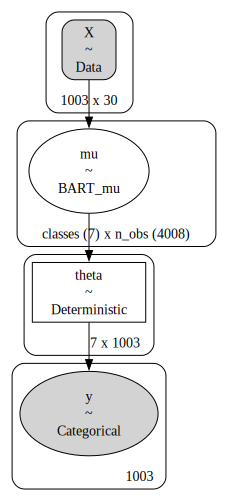

In [25]:
import pymc as pm
pm.model_to_graphviz(model=cat_wrapper.get_model())

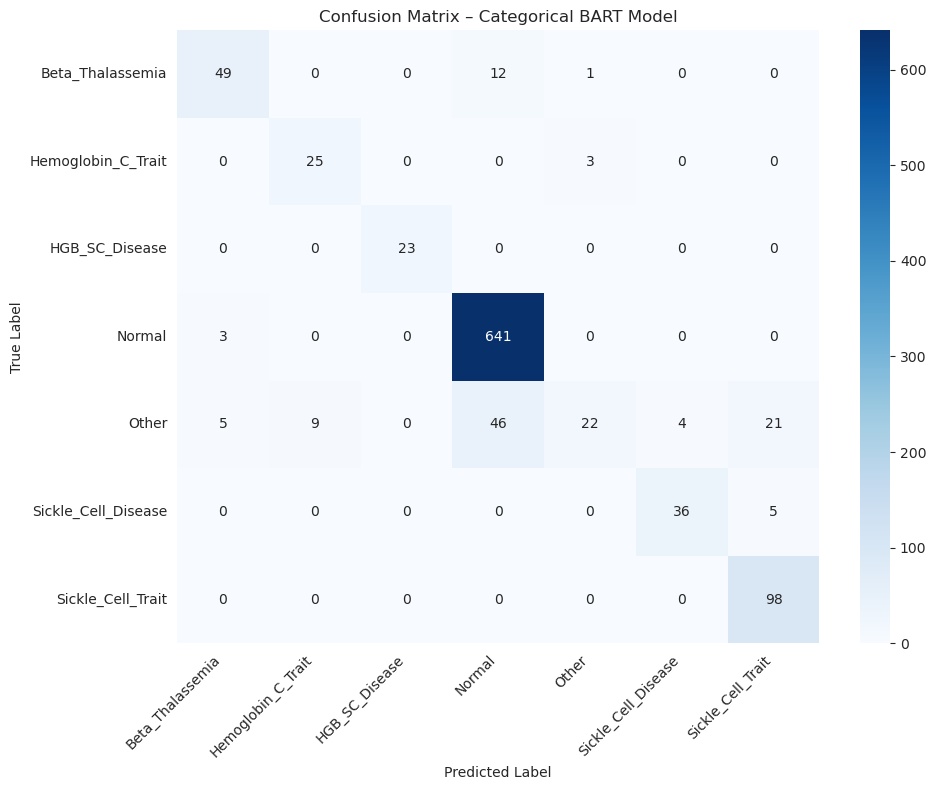


Classification Report – Categorical Model:
                     precision    recall  f1-score   support

   Beta_Thalassemia       0.86      0.79      0.82        62
 Hemoglobin_C_Trait       1.00      1.00      1.00        23
     HGB_SC_Disease       0.74      0.89      0.81        28
             Normal       0.92      1.00      0.95       644
              Other       0.85      0.21      0.33       107
Sickle_Cell_Disease       0.90      0.88      0.89        41
  Sickle_Cell_Trait       0.79      1.00      0.88        98

           accuracy                           0.89      1003
          macro avg       0.86      0.82      0.81      1003
       weighted avg       0.89      0.89      0.87      1003



In [19]:
# Confusion matrix for categorical model
y_true_cat = df_test[TARGET].values
y_pred_cat = results_cat["predicted_labels"]

cm_cat = confusion_matrix(y_true_cat, y_pred_cat, labels=cat_wrapper.category_codes_)

fig, ax = plt.subplots(figsize=(10, 8))
sns.heatmap(cm_cat, annot=True, fmt="d", cmap="Blues",
            xticklabels=cat_wrapper.category_codes_,
            yticklabels=cat_wrapper.category_codes_, ax=ax)
ax.set_xlabel("Predicted Label")
ax.set_ylabel("True Label")
ax.set_title("Confusion Matrix – Categorical BART Model")
plt.xticks(rotation=45, ha="right")
plt.yticks(rotation=0)
plt.tight_layout()
plt.show()

print("\nClassification Report – Categorical Model:")
print(classification_report(y_true_cat, y_pred_cat, target_names=list(cat_wrapper.category_codes_)))

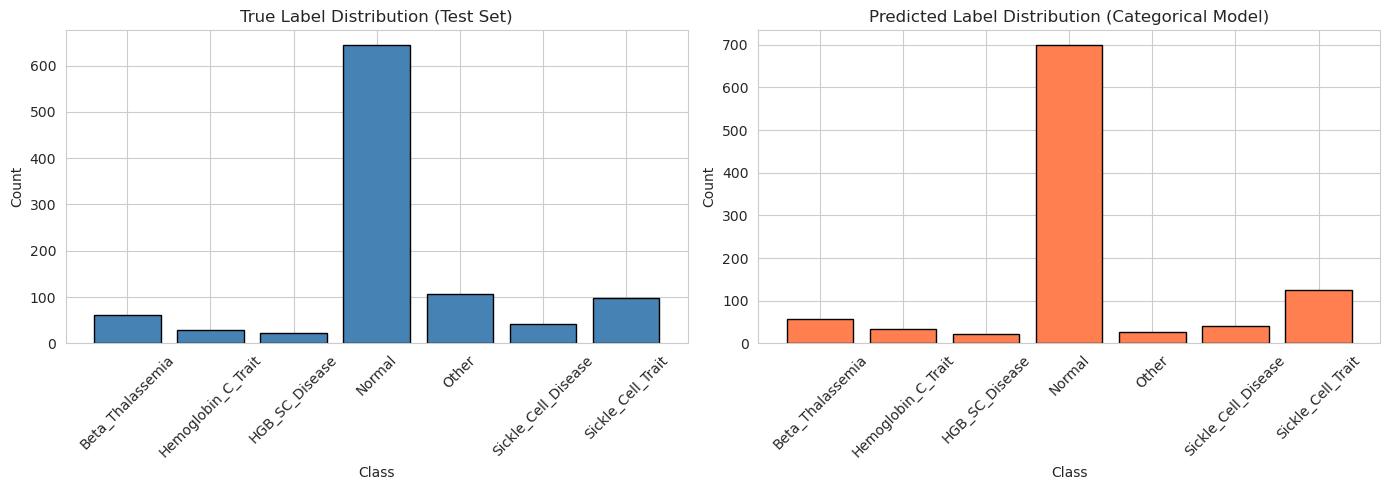

In [22]:
# Compare true vs predicted label distributions
fig, axes = plt.subplots(1, 2, figsize=(14, 5))
classes = list(cat_wrapper.category_codes_)

true_counts = pd.Series(y_true_cat).value_counts().reindex(classes, fill_value=0)
pred_counts = pd.Series(y_pred_cat).value_counts().reindex(classes, fill_value=0)

axes[0].bar(classes, true_counts, color="steelblue", edgecolor="black")
axes[0].set_title("True Label Distribution (Test Set)")
axes[0].set_xlabel("Class")
axes[0].set_ylabel("Count")
axes[0].tick_params(axis="x", rotation=45)

axes[1].bar(classes, pred_counts, color="coral", edgecolor="black")
axes[1].set_title("Predicted Label Distribution (Categorical Model)")
axes[1].set_xlabel("Class")
axes[1].set_ylabel("Count")
axes[1].tick_params(axis="x", rotation=45)

plt.tight_layout()
plt.show()

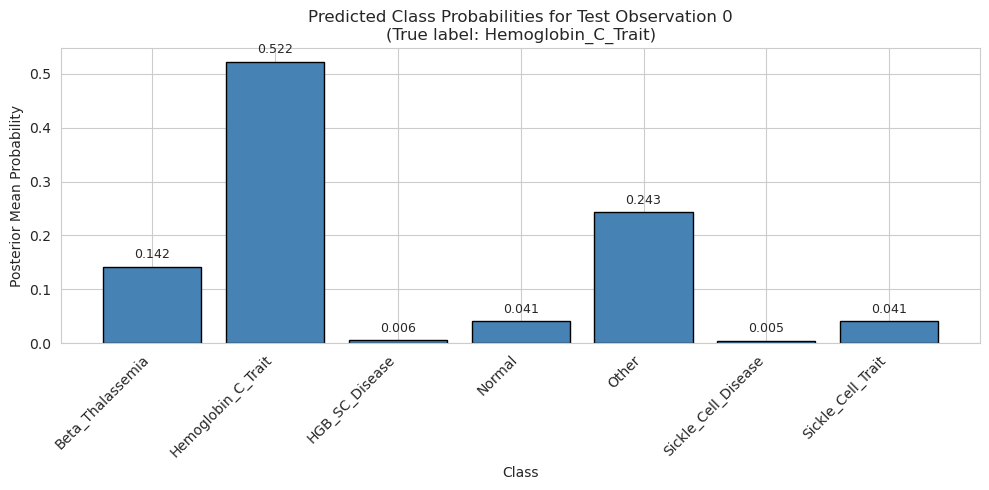

In [20]:
# Posterior predictive class probabilities for a single test observation
obs_idx = 0
probs = results_cat["class_prob_mean"][obs_idx]
classes = list(cat_wrapper.category_codes_)

fig, ax = plt.subplots(figsize=(10, 5))
bars = ax.bar(classes, probs, color="steelblue", edgecolor="black")
ax.set_xlabel("Class")
ax.set_ylabel("Posterior Mean Probability")
ax.set_title(f"Predicted Class Probabilities for Test Observation {obs_idx}\n"
             f"(True label: {df_test[TARGET].iloc[obs_idx]})")
plt.xticks(rotation=45, ha="right")
for bar, p in zip(bars, probs):
    ax.text(bar.get_x() + bar.get_width() / 2, bar.get_height() + 0.01,
            f"{p:.3f}", ha="center", va="bottom", fontsize=9)
plt.tight_layout()
plt.show()

---

## 6. Example B: Ordinal BART Model – Setup and Fit

For `target_type="ordinal"`, the wrapper builds a model that respects the **ordering** of the outcome classes using a cumulative logit (ordered logistic) likelihood. This follows the same general framework as the standard Bayesian ordered logistic regression described in the [PyMC Ordered Categories tutorial](https://www.pymc.io/projects/examples/en/latest/statistical_rethinking_lectures/11-Ordered_Categories.html), but replaces the linear predictor with a nonparametric BART function.

### Standard ordered logistic model

In a standard ordered logistic regression (as in the tutorial), the model is:

$$R_i \sim \text{OrderedLogistic}(\phi_i,\; \alpha), \qquad \phi_i = \mathbf{X}_i \boldsymbol{\beta}$$

where $\phi_i$ is a **linear predictor** and $\alpha_1 < \alpha_2 < \cdots < \alpha_{K-1}$ are ordered cutpoints. The cumulative probability of the response falling at or below category $k$ is:

$$P(Y \le k) = \sigma(\alpha_k - \phi_i)$$

where $\sigma$ is the logistic function, and class probabilities are obtained by differencing: $P(Y = k) = P(Y \le k) - P(Y \le k-1)$.

### BART ordinal model

The BART ordinal model replaces the linear predictor $\phi_i = \mathbf{X}_i \boldsymbol{\beta}$ with a nonparametric BART function $\mu_i = f_{\text{BART}}(\mathbf{X}_i)$, allowing the model to capture nonlinear and interaction effects while still respecting the ordinal structure through the same cumulative logistic likelihood:

1. `pmb.BART("mu", X, y, m=50)` — BART produces a single 1-D latent score `mu` per observation (replacing the linear predictor $\phi_i$ in the standard formulation). Higher `mu` shifts probability mass toward higher-order classes (because $P(Y \le k) = \sigma(c_k - \mu)$ decreases as $\mu$ increases).
2. `pm.Normal("cutpoints", ..., transform=ordered)` — A set of `n_classes - 1` learned cutpoints partition the real line into `n_classes` ordered bins. The `pm.distributions.transforms.univariate_ordered` transform ensures `cutpoints[0] < cutpoints[1] < ...`.
3. `pm.OrderedLogistic("y", eta=mu, cutpoints=cutpoints)` — The same `OrderedLogistic` likelihood used in the tutorial. It computes cumulative probabilities $P(Y \le k) = \sigma(c_k - \mu)$ and class probabilities by differencing: $P(Y = k) = P(Y \le k) - P(Y \le k-1)$.

In [26]:
# Define the ordinal ordering (low → high clinical severity)
ORDINAL_ORDER = [
    "Normal",
    "Hemoglobin_C_Trait",
    "Sickle_Cell_Trait",
    "Beta_Thalassemia",
    "HGB_SC_Disease",
    "Sickle_Cell_Disease",
    "Other",
]

# Instantiate the ordinal wrapper
ord_wrapper = BARTModelWrapper(
    target_var=TARGET,
    predictor_vars=PREDICTOR_VARS,
    non_numeric_vars=NON_NUMERIC_VARS,
    target_type="ordinal",           # ordered outcome
    ordinal_order=ORDINAL_ORDER,     # explicit severity ordering
    fill_missing=True,
)

# Pre-fit encoders on the full dataset
ord_wrapper.register_data(df)
print(ord_wrapper)

BARTModelWrapper(target='finalized_label', target_type='ordinal', n_predictors=22, fill_missing=True, encoding=full-data, status=not fitted)


In [27]:
# Fit the ordinal BART model
ord_wrapper.fit(
    df_train,
    m=50,
    chains=2,
    draws=500,
    tune=500,
    random_seed=42,
)
print("Ordinal model fitted.")

Sequential sampling (2 chains in 1 job)
CompoundStep
>PGBART: [mu]
>NUTS: [cutpoints]


Output()

Sampling 2 chains for 500 tune and 500 draw iterations (1_000 + 1_000 draws total) took 238 seconds.
Sampling: [y]


Output()

Ordinal model fitted.


### Example B: Out-of-Sample Prediction

Generate predictions from the ordinal model on the same test set.

In [28]:
# Predict on held-out test data with the ordinal model
results_ord = ord_wrapper.predict(df_test, random_seed=42)

print(f"Ordinal – predicted labels (first 10): {results_ord['predicted_labels'][:10]}")
print(f"Ordinal – class prob mean shape: {results_ord['class_prob_mean'].shape}")

Sampling: [mu, y]


Output()

Ordinal – predicted labels (first 10): ['Normal', 'Normal', 'Other', 'Normal', 'Other', 'Normal', 'Normal', 'Normal', 'Normal', 'Sickle_Cell_Trait']
Ordinal – class prob mean shape: (1003, 7)


In [29]:
# Display predicted class probabilities for the first 5 test observations (ordinal)
prob_df_ord = pd.DataFrame(
    results_ord['class_prob_mean'][:5],
    columns=ORDINAL_ORDER,
    index=[f"Obs {i}" for i in range(5)]
)
print("Posterior mean class probabilities – Ordinal Model (first 5 test observations):")
prob_df_ord

Posterior mean class probabilities – Ordinal Model (first 5 test observations):


,Normal,Hemoglobin_C_Trait,Sickle_Cell_Trait,Beta_Thalassemia,HGB_SC_Disease,Sickle_Cell_Disease,Other
Obs 0,0.235,0.068,0.233,0.145,0.042,0.085,0.192
Obs 1,0.379,0.067,0.214,0.117,0.043,0.050,0.130
Obs 2,0.149,0.042,0.191,0.142,0.068,0.095,0.313
Obs 3,0.972,0.010,0.013,0.003,0.001,0.000,0.001
Obs 4,0.097,0.038,0.172,0.153,0.062,0.106,0.372


### Example B: Visualize Ordinal Model Results

Evaluate the ordinal model with the same visualizations, using the ordinal class ordering. We also plot cumulative predicted probabilities for a single observation, which is a natural visualization for ordinal models.

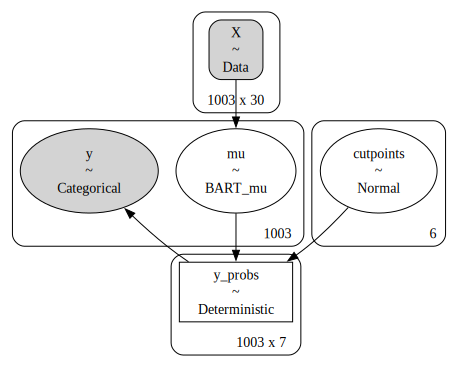

In [36]:
import pymc as pm
pm.model_to_graphviz(model=ord_wrapper.get_model())

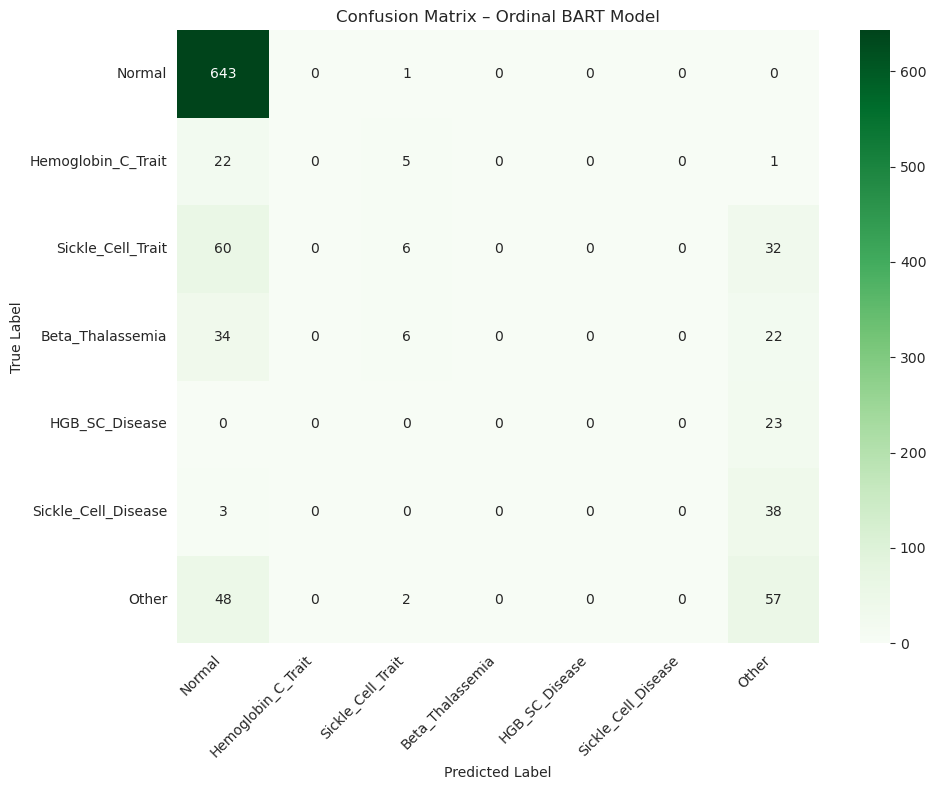


Classification Report – Ordinal Model:
                     precision    recall  f1-score   support

             Normal       0.00      0.00      0.00        62
 Hemoglobin_C_Trait       0.00      0.00      0.00        23
  Sickle_Cell_Trait       0.00      0.00      0.00        28
   Beta_Thalassemia       0.79      1.00      0.88       644
     HGB_SC_Disease       0.33      0.53      0.41       107
Sickle_Cell_Disease       0.00      0.00      0.00        41
              Other       0.30      0.06      0.10        98

           accuracy                           0.70      1003
          macro avg       0.20      0.23      0.20      1003
       weighted avg       0.57      0.70      0.62      1003



/home/kimh31/miniconda3/envs/cnv/lib/python3.11/site-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
/home/kimh31/miniconda3/envs/cnv/lib/python3.11/site-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
/home/kimh31/miniconda3/envs/cnv/lib/python3.11/site-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} i

In [30]:
# Confusion matrix for ordinal model
y_true_ord = df_test[TARGET].values
y_pred_ord = results_ord["predicted_labels"]

cm_ord = confusion_matrix(y_true_ord, y_pred_ord, labels=ORDINAL_ORDER)

fig, ax = plt.subplots(figsize=(10, 8))
sns.heatmap(cm_ord, annot=True, fmt="d", cmap="Greens",
            xticklabels=ORDINAL_ORDER,
            yticklabels=ORDINAL_ORDER, ax=ax)
ax.set_xlabel("Predicted Label")
ax.set_ylabel("True Label")
ax.set_title("Confusion Matrix – Ordinal BART Model")
plt.xticks(rotation=45, ha="right")
plt.yticks(rotation=0)
plt.tight_layout()
plt.show()

print("\nClassification Report – Ordinal Model:")
print(classification_report(y_true_ord, y_pred_ord, target_names=ORDINAL_ORDER))

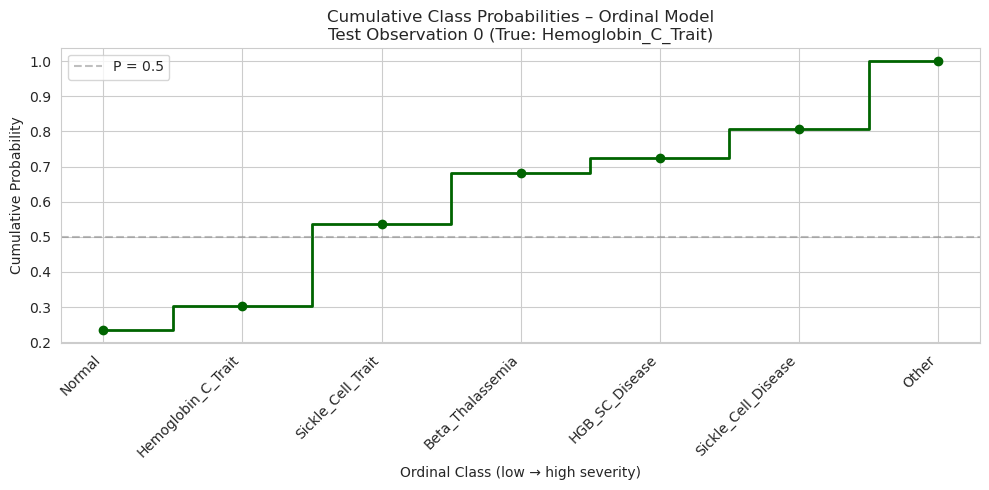

In [32]:
# Cumulative predicted probabilities for the ordinal model (single observation)
obs_idx = 0
probs_ord = results_ord["class_prob_mean"][obs_idx]
cum_probs = np.cumsum(probs_ord)

fig, ax = plt.subplots(figsize=(10, 5))
ax.step(range(len(ORDINAL_ORDER)), cum_probs, where="mid",
        color="darkgreen", linewidth=2, marker="o")
ax.set_xticks(range(len(ORDINAL_ORDER)))
ax.set_xticklabels(ORDINAL_ORDER, rotation=45, ha="right")
ax.set_xlabel("Ordinal Class (low → high severity)")
ax.set_ylabel("Cumulative Probability")
ax.set_title(f"Cumulative Class Probabilities – Ordinal Model\n"
             f"Test Observation {obs_idx} (True: {df_test[TARGET].iloc[obs_idx]})")
ax.axhline(0.5, color="gray", linestyle="--", alpha=0.5, label="P = 0.5")
ax.legend()
plt.tight_layout()
plt.show()

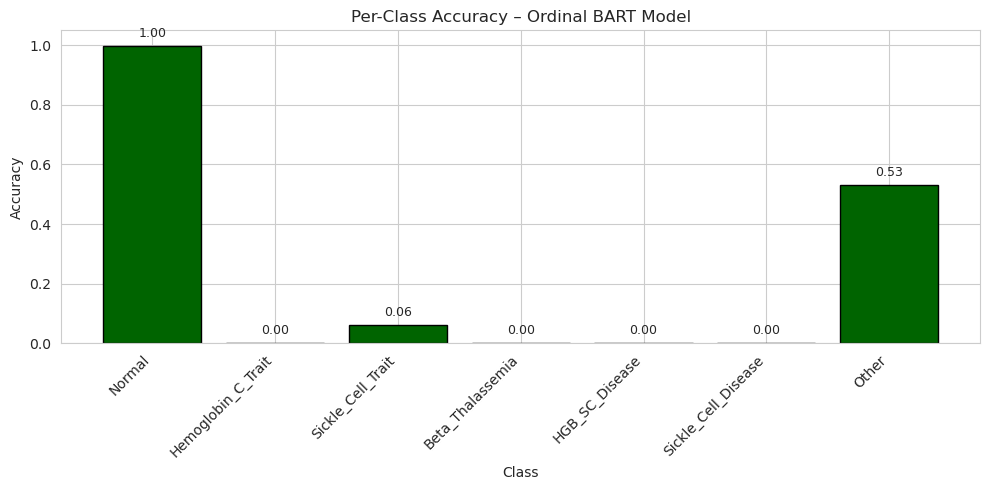

In [31]:
# Per-class accuracy for the ordinal model
per_class_acc_ord = {}
for cls in ORDINAL_ORDER:
    mask = y_true_ord == cls
    if mask.sum() > 0:
        per_class_acc_ord[cls] = (np.array(y_pred_ord)[mask] == y_true_ord[mask]).mean()
    else:
        per_class_acc_ord[cls] = 0.0

fig, ax = plt.subplots(figsize=(10, 5))
bars = ax.bar(per_class_acc_ord.keys(), per_class_acc_ord.values(),
              color="darkgreen", edgecolor="black")
ax.set_xlabel("Class")
ax.set_ylabel("Accuracy")
ax.set_title("Per-Class Accuracy – Ordinal BART Model")
ax.set_ylim(0, 1.05)
plt.xticks(rotation=45, ha="right")
for bar, acc in zip(bars, per_class_acc_ord.values()):
    ax.text(bar.get_x() + bar.get_width() / 2, bar.get_height() + 0.02,
            f"{acc:.2f}", ha="center", va="bottom", fontsize=9)
plt.tight_layout()
plt.show()

---

## 7. Accuracy Comparison Between Categorical and Ordinal Models

Let's compute and compare the overall accuracy and per-class accuracy of both models on the same test set.

In [33]:
# Overall accuracy comparison
y_true_labels = df_test[TARGET].values
acc_cat = accuracy_score(y_true_labels, results_cat["predicted_labels"])
acc_ord = accuracy_score(y_true_labels, results_ord["predicted_labels"])

print(f"Categorical accuracy: {acc_cat:.3f}")
print(f"Ordinal     accuracy: {acc_ord:.3f}")

# Per-class accuracy for both models
all_classes = list(cat_wrapper.category_codes_)
per_class_cat = {}
per_class_ord = {}
for cls in all_classes:
    mask = y_true_labels == cls
    if mask.sum() > 0:
        per_class_cat[cls] = (np.array(results_cat["predicted_labels"])[mask] == y_true_labels[mask]).mean()
        per_class_ord[cls] = (np.array(results_ord["predicted_labels"])[mask] == y_true_labels[mask]).mean()
    else:
        per_class_cat[cls] = 0.0
        per_class_ord[cls] = 0.0

comparison_df = pd.DataFrame({
    "Categorical Accuracy": per_class_cat,
    "Ordinal Accuracy": per_class_ord,
})
comparison_df.loc["Overall"] = [acc_cat, acc_ord]
comparison_df

Categorical accuracy: 0.891
Ordinal     accuracy: 0.704


,Categorical Accuracy,Ordinal Accuracy
Beta_Thalassemia,0.790323,0.000000
Hemoglobin_C_Trait,0.892857,0.000000
HGB_SC_Disease,1.000000,0.000000
Normal,0.995342,0.998447
Other,0.205607,0.532710
Sickle_Cell_Disease,0.878049,0.000000
Sickle_Cell_Trait,1.000000,0.061224
Overall,0.891326,0.703888


## 8. Visualize Accuracy Comparison

A side-by-side comparison of per-class accuracy for both models, plus an overall accuracy summary.

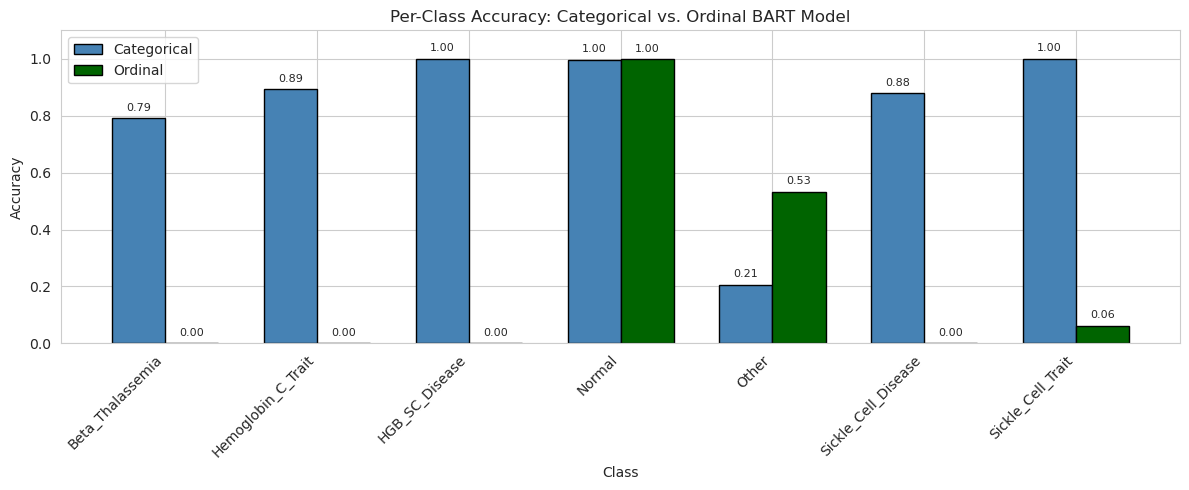

In [34]:
# Grouped bar chart: per-class accuracy comparison
x = np.arange(len(all_classes))
width = 0.35

fig, ax = plt.subplots(figsize=(12, 5))
bars1 = ax.bar(x - width/2, [per_class_cat[c] for c in all_classes],
               width, label="Categorical", color="steelblue", edgecolor="black")
bars2 = ax.bar(x + width/2, [per_class_ord[c] for c in all_classes],
               width, label="Ordinal", color="darkgreen", edgecolor="black")

ax.set_xlabel("Class")
ax.set_ylabel("Accuracy")
ax.set_title("Per-Class Accuracy: Categorical vs. Ordinal BART Model")
ax.set_xticks(x)
ax.set_xticklabels(all_classes, rotation=45, ha="right")
ax.set_ylim(0, 1.1)
ax.legend()

for bar in bars1:
    ax.text(bar.get_x() + bar.get_width() / 2, bar.get_height() + 0.02,
            f"{bar.get_height():.2f}", ha="center", va="bottom", fontsize=8)
for bar in bars2:
    ax.text(bar.get_x() + bar.get_width() / 2, bar.get_height() + 0.02,
            f"{bar.get_height():.2f}", ha="center", va="bottom", fontsize=8)

plt.tight_layout()
plt.show()